# Stat 153/248 - Lecture 18

In this notebook we'll work through three real datasets that motivate why we need AR, MA, and ARMA models. We'll use the following datasets:

1. **Sunspot numbers**
2. **US gas prices** 
3. **Heart rate variability (HRV)**

By the end, you should have an intuition for when each model class is appropriate and why ARMA exists as a modeling framework.

In [158]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

# statsmodels imports
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

plt.rcParams.update({
    'figure.figsize': (12, 4),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 16,
})

---
## The AR Model - Sunspot Numbers 

We've already seen this dataset in several contexts, which records the monthly mean number of sunspots from 1749 to the present. This series has a well-known ~11-year cycle.

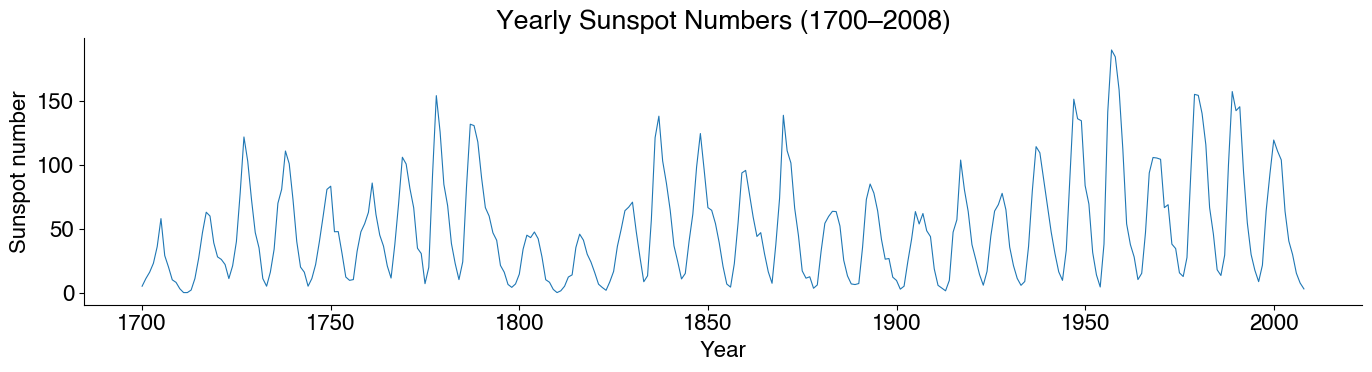

In [159]:
# Sunspot data is in the statsmodels package (as well as astsa, but here we don't need it!)
import statsmodels.api as sm
sunspots = sm.datasets.sunspots.load_pandas().data
sunspots.columns = ['year', 'sunspots']
sunspots = sunspots.set_index('year')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(sunspots.index, sunspots['sunspots'], linewidth=0.8)
ax.set(xlabel='Year', ylabel='Sunspot number', title='Yearly Sunspot Numbers (1700–2008)')
plt.tight_layout()
plt.show()


### Predict (pair discussion, 2 min)

Before we look at the ACF and PACF:

1. **What kind of autocorrelation structure do you expect?** Slowly decaying? Oscillating? Sharp cutoff?
2. **If you had to guess: AR, MA, or ARMA?** Why?
3. **How many parameters do you think you'd need?**

Write down your predictions before running the next cell.


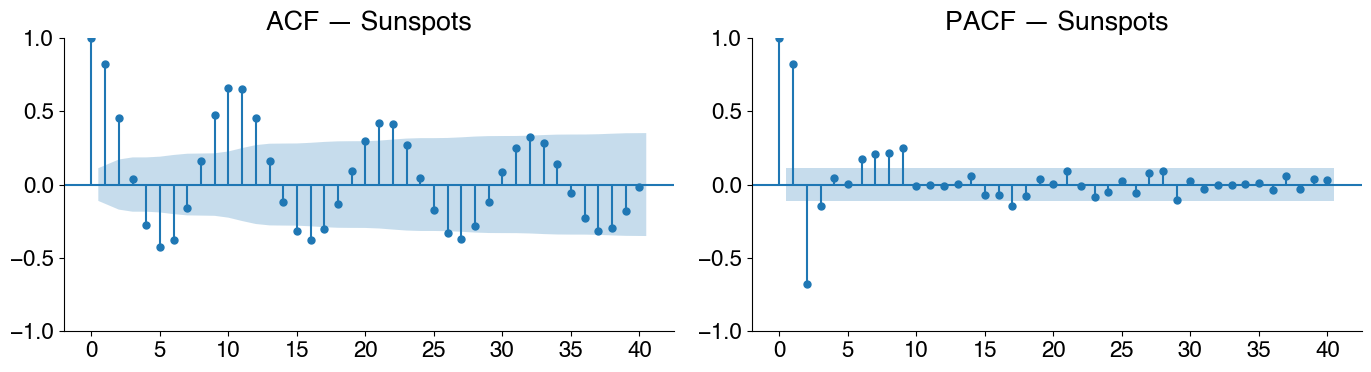

In [160]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(sunspots['sunspots'].dropna(), lags=40, ax=axes[0], title='ACF — Sunspots')
plot_pacf(sunspots['sunspots'].dropna(), lags=40, ax=axes[1], title='PACF — Sunspots', method='ywm')

plt.tight_layout()
plt.show()


# What do we see?

Notice that we have the following behavior:

- **ACF**: Slowly decaying, oscillatory. The 11-year cycle shows up as a damped sinusoid in the ACF. 
- **PACF**: Drops sharply after lag 2. This is the signature of an **AR(2)** process.

The remarkable thing: just **two coefficients** are enough to generate quasi-periodic behavior. Let's fit it.


In [168]:
# Let's fit an AR(2) model to the sunspot dataset

y_sun = sunspots['sunspots'].dropna().values

ar2_model = ARIMA(y_sun, order=(2, 0, 0)).fit()
print(ar2_model.summary().tables[1])
print(f"\nAR(2) coefficients: φ₁ = {ar2_model.params[1]:.4f}, φ₂ = {ar2_model.params[2]:.4f}")

# Check the characteristic roots
ar_poly = np.array([1, -ar2_model.params[1], -ar2_model.params[2]])
roots = np.roots(ar_poly)
print(f"\nCharacteristic roots: {roots}")
print(f"Modulus: {np.abs(roots)}")
if np.any(np.iscomplex(roots)):
    period = 2 * np.pi / np.abs(np.angle(roots[0]))
    print(f"Implied period: {period:.1f} years  (actual sunspot cycle ≈ 11 years)")


                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         49.7462      3.938     12.631      0.000      42.027      57.465
ar.L1          1.3906      0.037     37.694      0.000       1.318       1.463
ar.L2         -0.6886      0.036    -19.363      0.000      -0.758      -0.619
sigma2       274.7272     18.897     14.538      0.000     237.689     311.765

AR(2) coefficients: φ₁ = 1.3906, φ₂ = -0.6886

Characteristic roots: [0.69531643+0.45288847j 0.69531643-0.45288847j]
Modulus: [0.82980293 0.82980293]
Implied period: 10.9 years  (actual sunspot cycle ≈ 11 years)


## Check residuals

We can now look at the residuals for the AR(2) model to determine whether we've fully captured the periodic activity in our time series. If the residuals look like white noise and have ACF and PACF peaking only at 0 (indicating no further correlation structure), then our model has done a good job.

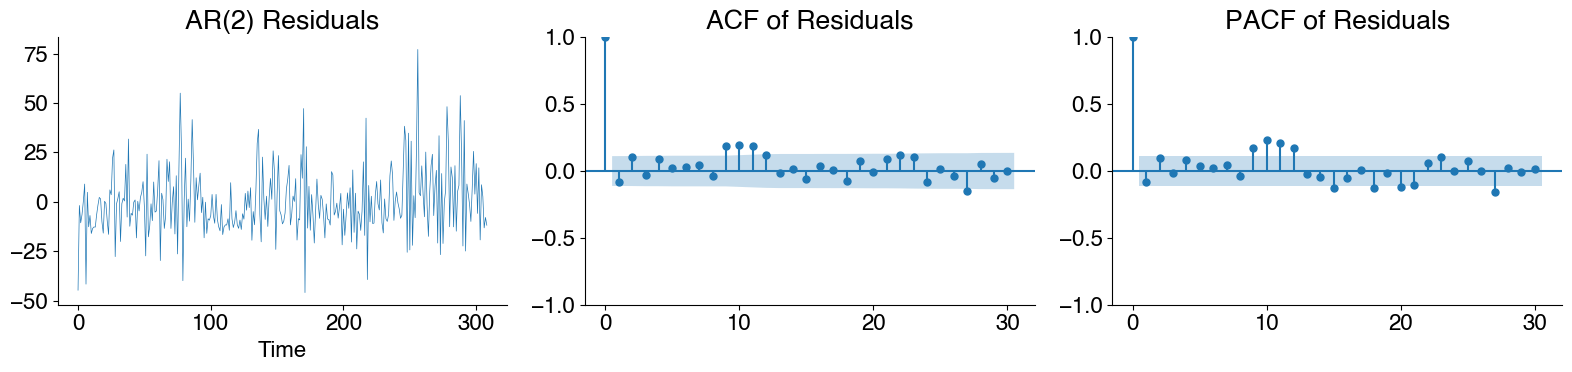

In [169]:
# Residual diagnostics for AR(2)
resid_ar2 = ar2_model.resid

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(resid_ar2, linewidth=0.5)
axes[0].set(title='AR(2) Residuals', xlabel='Time')

plot_acf(resid_ar2, lags=30, ax=axes[1], title='ACF of Residuals')
plot_pacf(resid_ar2, lags=30, ax=axes[2], title='PACF of Residuals', method='ywm')

plt.tight_layout()
plt.show()


## Results

AR(2) does a good job on sunspots. Two coefficients with complex roots produce damped oscillations that match the ~11-year solar cycle. The residuals are nearly white noise (though we haven't entirely removed the periodicity).

AR models are powerful when the current value depends on recent past values through a recursive/autoregressive relationship. As seen in this example, the ACF will decay gradually, while the PACF cuts off.

Not every time series has this clean structure, so let's look at a slightly more complex example.

## The AR model and Gas Prices

Gas prices are extremely topical right now. Between early and mid-March 2026, the national average for regular gasoline jumped significantly. Gas price data has relatively strong persistence, but also responds to **shocks** (conflict, policy changes) that create short-lived perturbations.

We'll use [data from FRED](https://fred.stlouisfed.org/series/GASREGW) (Federal Reserve Economic Data).

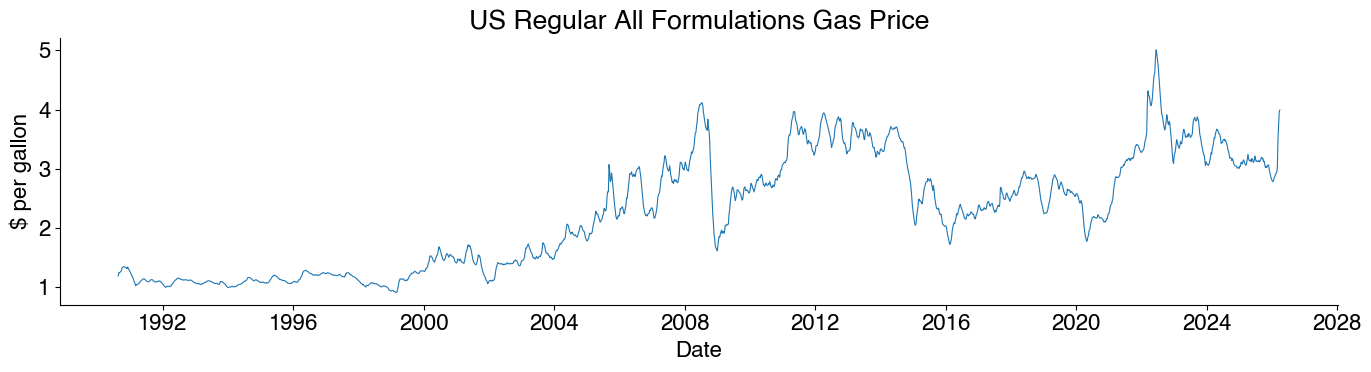

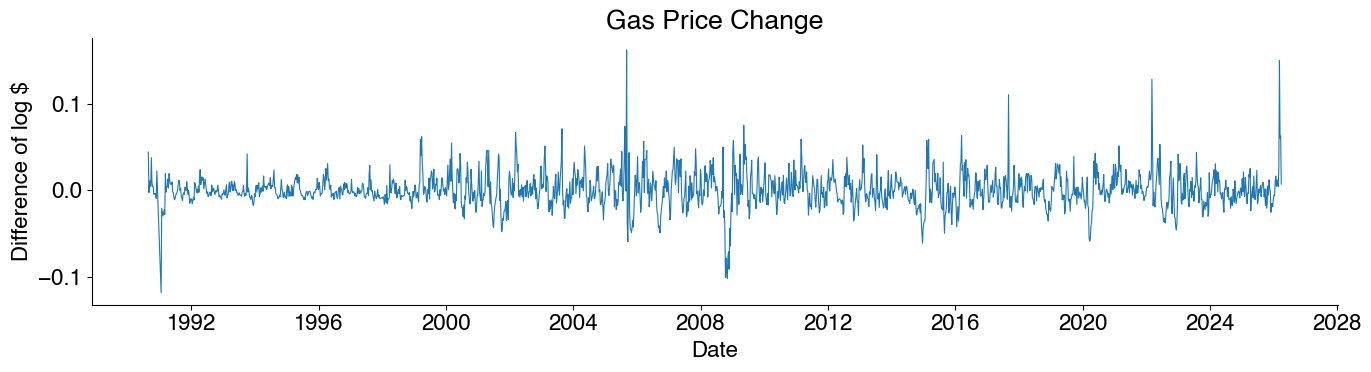

Series length: 1853 observations
Mean: 2.26, Std: 0.95


In [170]:
# US Regular All Formulations Gas Price
# Source: FRED series GASREGW

gas = pd.read_csv('GASREGW.csv', parse_dates=['observation_date'], index_col='observation_date').dropna()
y_gas = gas['GASREGW'].values
log_change = np.diff(np.log(y_gas))

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(gas.index, y_gas, linewidth=0.8)
ax.set(xlabel='Date', ylabel='$ per gallon', 
       title='US Regular All Formulations Gas Price')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(gas.index[1:], log_change, linewidth=0.8)
ax.set(xlabel='Date', ylabel='Difference of log $', 
       title='Gas Price Change')
plt.tight_layout()
plt.show()

print(f"Series length: {len(y_gas)} observations")
print(f"Mean: {np.mean(y_gas):.2f}, Std: {np.std(y_gas):.2f}")


### Predict (1 min)

1. Based on the plot, do you expect the ACF to decay faster or slower than sunspots?
2. Will the PACF cut off as cleanly as it did for sunspots?


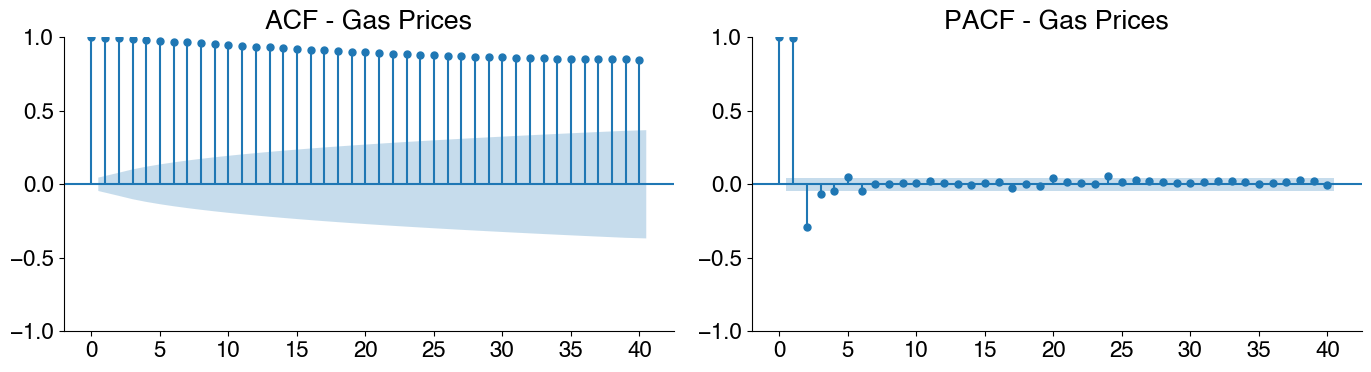

In [171]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(y_gas, lags=40, ax=axes[0], title='ACF - Gas Prices')
plot_pacf(y_gas, lags=40, ax=axes[1], title='PACF - Gas Prices', method='ywm')

plt.tight_layout()
plt.show()

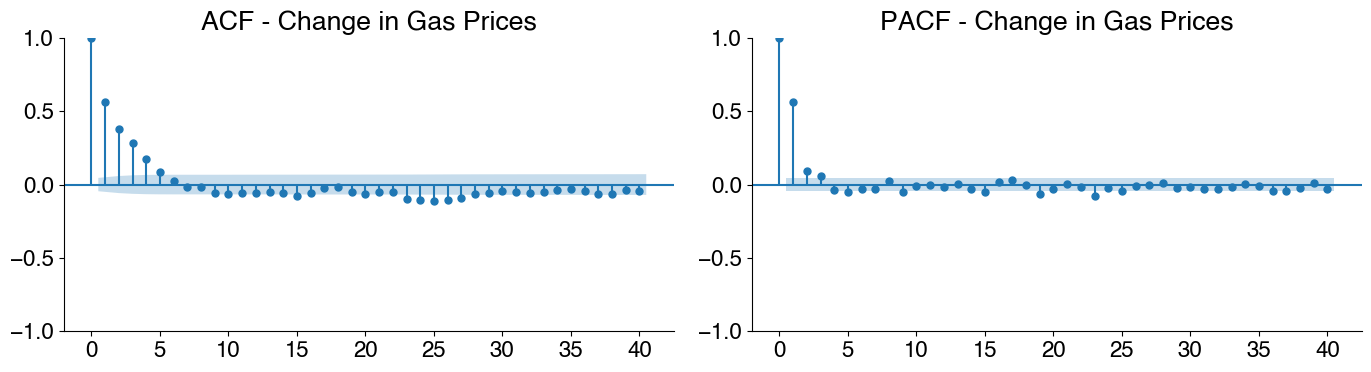

In [172]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(log_change, lags=40, ax=axes[0], title='ACF - Change in Gas Prices')
plot_pacf(log_change, lags=40, ax=axes[1], title='PACF - Change in Gas Prices', method='ywm')

plt.tight_layout()
plt.show()

### Results

The ACF decays very slowly for the original series — this series has high persistence (almost unit-root behavior). The PACF shows a strong spike at lag 1, smaller spike at lag 2, and then starts to cut off. When we difference the signal, the ACF falls off more quickly.

Let's try fitting AR models of increasing order and see what the residuals look like.


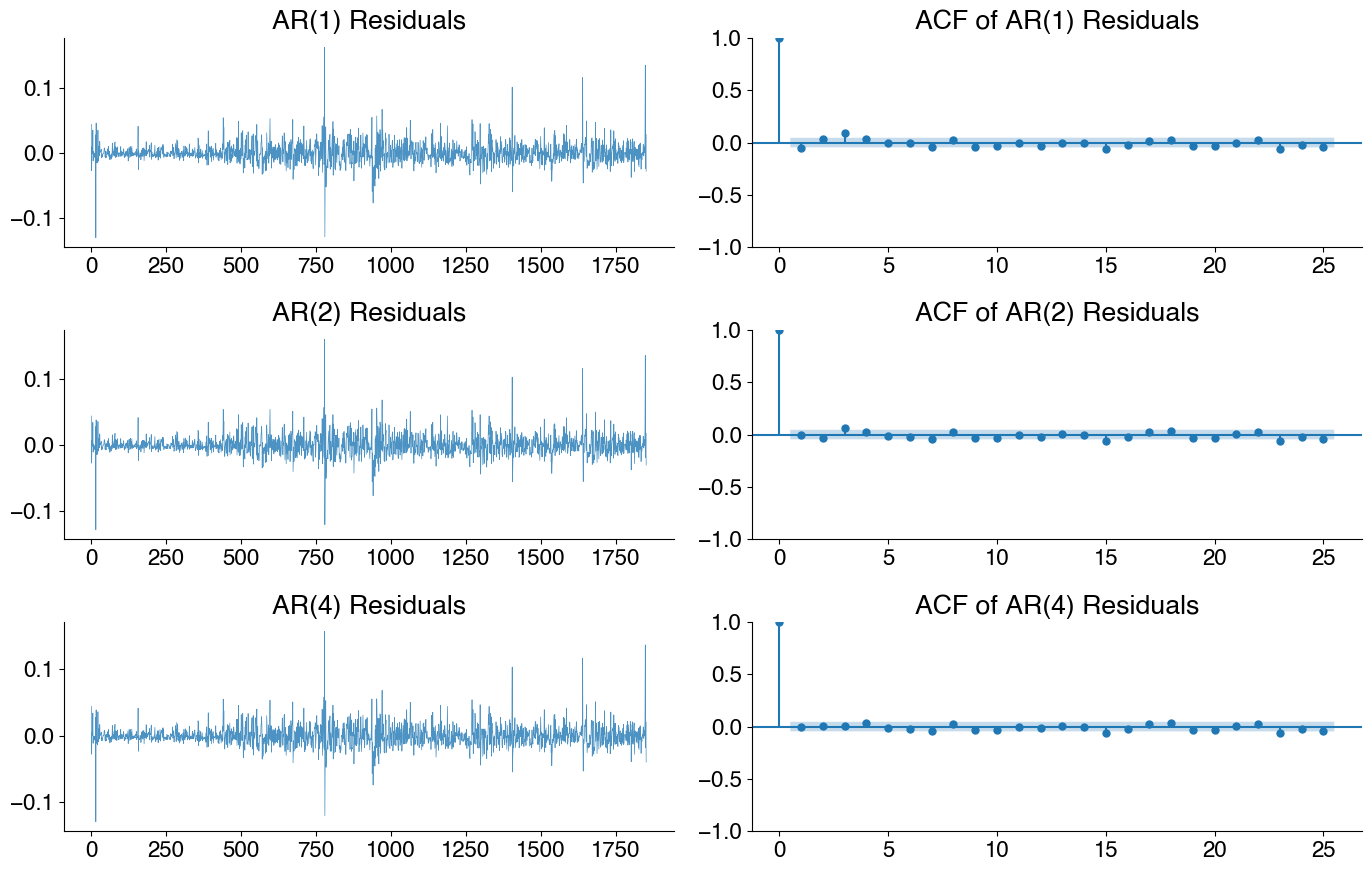

In [174]:
# Fit AR(1), AR(2), AR(4) and compare
orders = [1, 2, 4]
fig, axes = plt.subplots(len(orders), 2, figsize=(14, 3*len(orders)))

for i, p in enumerate(orders):
    model = ARIMA(log_change, order=(p, 0, 0)).fit()
    resid = model.resid
    
    axes[i, 0].plot(resid, linewidth=0.5, alpha=0.8)
    axes[i, 0].set(title=f'AR({p}) Residuals')
    
    plot_acf(resid, lags=25, ax=axes[i, 1], title=f'ACF of AR({p}) Residuals')

plt.tight_layout()
plt.show()


## An MA model

Let's try fitting an MA model to these data instead. What do you think will happen? Is this going to work?

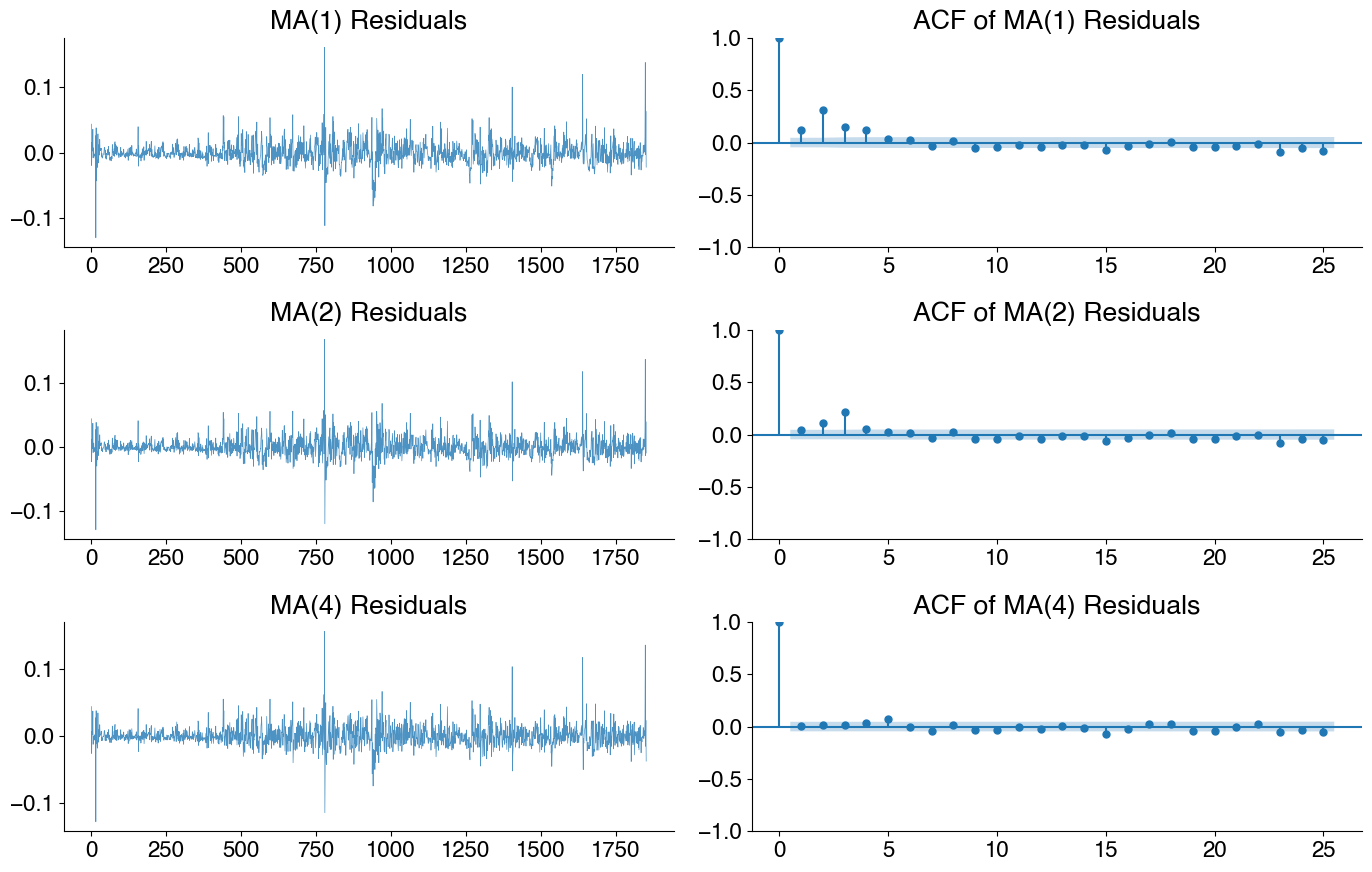

In [176]:
# Fit MA(1), MA(2), MA(4) and compare
orders = [1, 2, 4]
fig, axes = plt.subplots(len(orders), 2, figsize=(14, 3*len(orders)))

for i, q in enumerate(orders):
    model = ARIMA(log_change, order=(0, 0, q)).fit()
    resid = model.resid
    
    axes[i, 0].plot(resid, linewidth=0.5, alpha=0.8)
    axes[i, 0].set(title=f'MA({q}) Residuals')
    
    plot_acf(resid, lags=25, ax=axes[i, 1], title=f'ACF of MA({q}) Residuals')

plt.tight_layout()
plt.show()


## ARMA model

Now we'll try a combination of the AR and the MA models - a two parameter model.

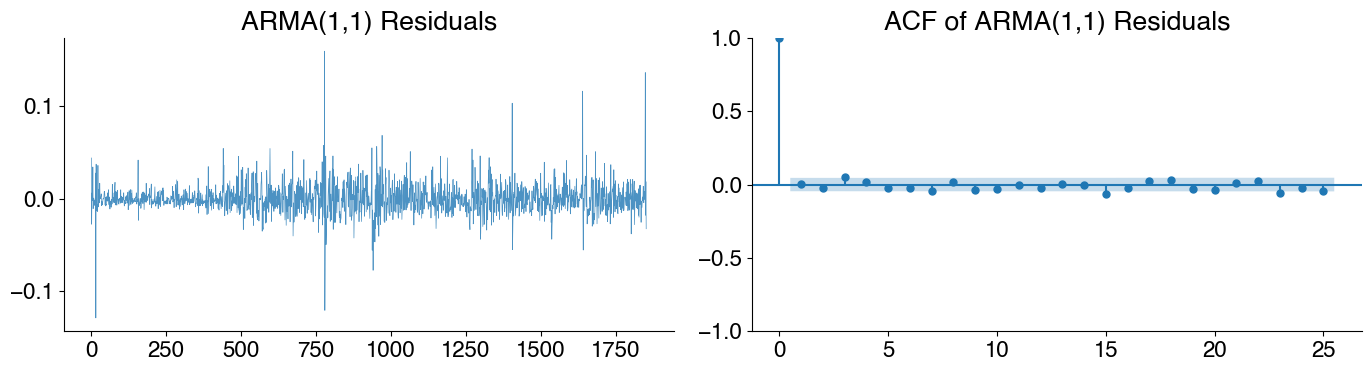

In [177]:
# Now try ARMA(1,1) — one AR + one MA coefficient
arma11 = ARIMA(log_change, order=(1, 0, 1)).fit()
resid_arma = arma11.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(resid_arma, linewidth=0.5, alpha=0.8)
axes[0].set(title=f'ARMA(1,1) Residuals')

plot_acf(resid_arma, lags=25, ax=axes[1], title='ACF of ARMA(1,1) Residuals')

plt.tight_layout()
plt.show()

## Using the models for forecasting

To look at performance of the models, we could use techniques like AIC/BIC, or we can go back to using them more general method of cross-validation. Here we will use a very simple train/test split, though you can also try methods like rolling cross-validation (where your training set grows for each fold, or using a fixed-width sliding window). 

In [181]:
# Split the data using the last 3 years as the test set (data are in weeks)
t = 3    #*52

y_train = log_change[:-t]
y_test = log_change[-t:]

print(f"Train: {len(y_train)} obs, Test: {len(y_test)} obs")

models_to_test = {
    'AR(1)':     (1, 0, 0),
    'AR(2)':     (2, 0, 0),
    'AR(3)':     (3, 0, 0),
    'AR(4)':     (4, 0, 0),
    'ARMA(1,1)': (1, 0, 1),
    'ARMA(2,1)': (2, 0, 1),
    'ARMA(3,1)': (3, 0, 1),
}

results = {}
for name, order in models_to_test.items():
    model = ARIMA(y_train, order=order).fit()
    forecasts = model.forecast(steps=len(y_test))
    errors = y_test - forecasts
    results[name] = {
        'rmse': np.sqrt(np.mean(errors**2)),
        'mae': np.mean(np.abs(errors)),
        'forecasts': forecasts,
        'errors': errors,
    }
    print(f"{name:<12} RMSE={results[name]['rmse']:.5f}")

Train: 1849 obs, Test: 3 obs
AR(1)        RMSE=0.02041
AR(2)        RMSE=0.02074
AR(3)        RMSE=0.02322
AR(4)        RMSE=0.02445
ARMA(1,1)    RMSE=0.02099
ARMA(2,1)    RMSE=0.02565
ARMA(3,1)    RMSE=0.02379


## Discussion

Let's look at the RMSE results. Discuss:

1. Does adding more AR lags keep helping?
2. How does ARMA(1,1) compare to the pure AR models?
3. **Conceptually**: why might gas prices have *both* AR and MA structure?  

# Let's look at forecasting results

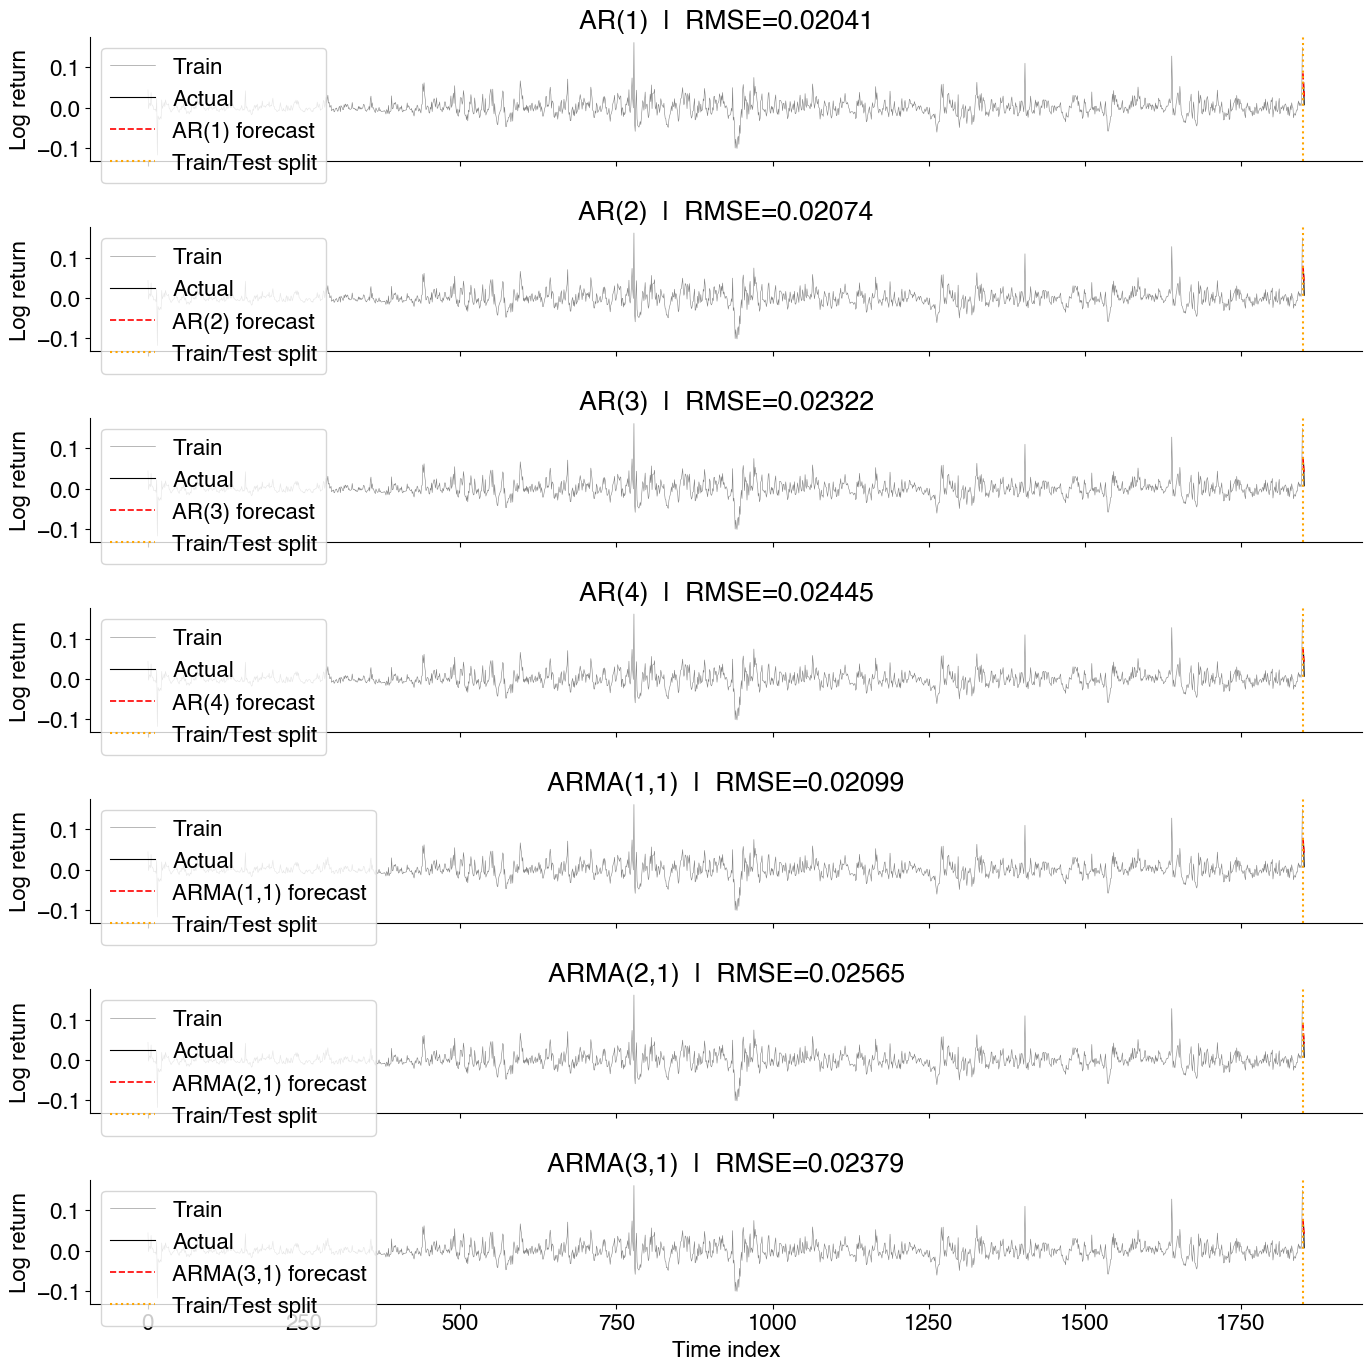

In [182]:
fig, axes = plt.subplots(len(results), 1, figsize=(14, 2 * len(results)), sharex=True)

split_point = len(y_train)

for ax, (name, res) in zip(axes, results.items()):
    # Training data
    ax.plot(np.arange(len(y_train)), y_train, 'k-', linewidth=0.4, alpha=0.5, label='Train')
    # Test actual
    ax.plot(np.arange(split_point, split_point + len(y_test)), y_test, 'k-', linewidth=0.8, label='Actual')
    # Forecast
    ax.plot(np.arange(split_point, split_point + len(y_test)), res['forecasts'], 'r--', linewidth=1.2, label=f'{name} forecast')
    # Split line
    ax.axvline(split_point, color='orange', linewidth=1.5, linestyle=':', label='Train/Test split')
    ax.set(ylabel='Log return', title=f'{name}  |  RMSE={res["rmse"]:.5f}')
    ax.legend(loc='upper left')

axes[-1].set(xlabel='Time index')
plt.tight_layout()
plt.show()

Best model: AR(1)


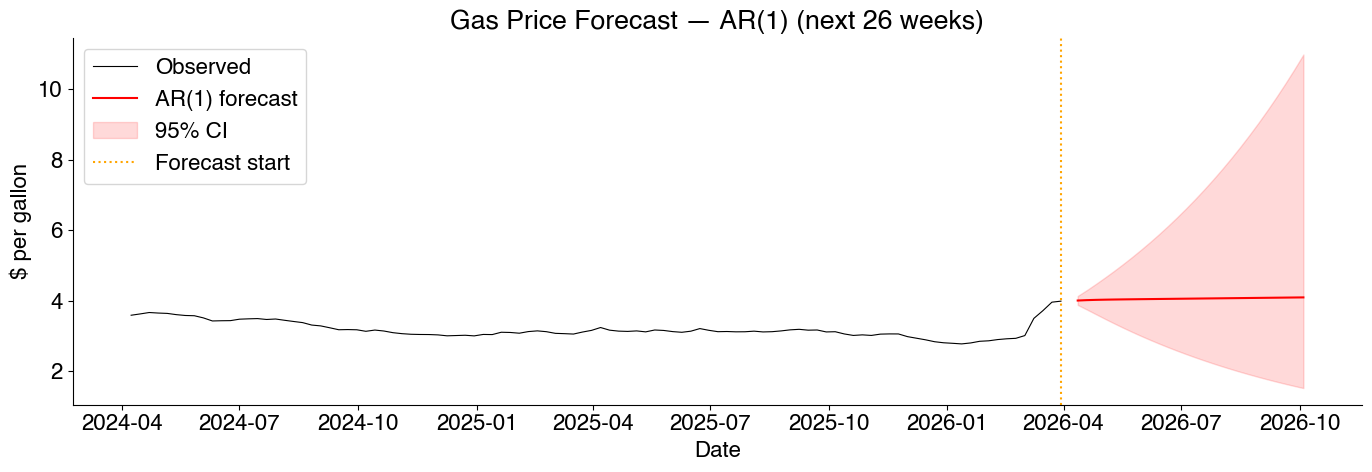


Current price: $3.99
Forecast in 26 weeks: $4.10
95% CI: [$1.53, $10.98]


In [183]:
# Pick the best model by RMSE
best_name = min(results, key=lambda n: results[n]['rmse'])
best_order = models_to_test[best_name]
print(f"Best model: {best_name}")

# Refit on ALL data, then forecast into the future
full_model = ARIMA(log_change, order=best_order).fit()

n_ahead = 26  # 26 weeks ~ 6 months
forecast_result = full_model.get_forecast(steps=n_ahead)
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int(alpha=0.05)  # 95% CI

# Convert log returns back to prices
last_price = y_gas[-1]
# Cumulative sum of log returns -> multiply by last observed price
future_prices = last_price * np.exp(np.cumsum(forecast_mean))
ci_lower = last_price * np.exp(np.cumsum(forecast_ci[:, 0]))
ci_upper = last_price * np.exp(np.cumsum(forecast_ci[:, 1]))

# Build future date index
last_date = gas.index[-1]
future_dates = pd.date_range(last_date, periods=n_ahead + 1, freq='W')[1:]

# Plot
fig, ax = plt.subplots(figsize=(14, 5))

# Historical prices (last 2 years for context)
lookback = 104
ax.plot(gas.index[-lookback:], y_gas[-lookback:], 'k-', linewidth=0.8, label='Observed')

# Forecast
ax.plot(future_dates, future_prices, 'r-', linewidth=1.5, label=f'{best_name} forecast')
ax.fill_between(future_dates, ci_lower, ci_upper, color='red', alpha=0.15, label='95% CI')

# Split line
ax.axvline(gas.index[-1], color='orange', linewidth=1.5, linestyle=':', label='Forecast start')

ax.set(xlabel='Date', ylabel='$ per gallon',
       title=f'Gas Price Forecast — {best_name} (next {n_ahead} weeks)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nCurrent price: ${last_price:.2f}")
print(f"Forecast in {n_ahead} weeks: ${future_prices[-1]:.2f}")
print(f"95% CI: [${ci_lower[-1]:.2f}, ${ci_upper[-1]:.2f}]")

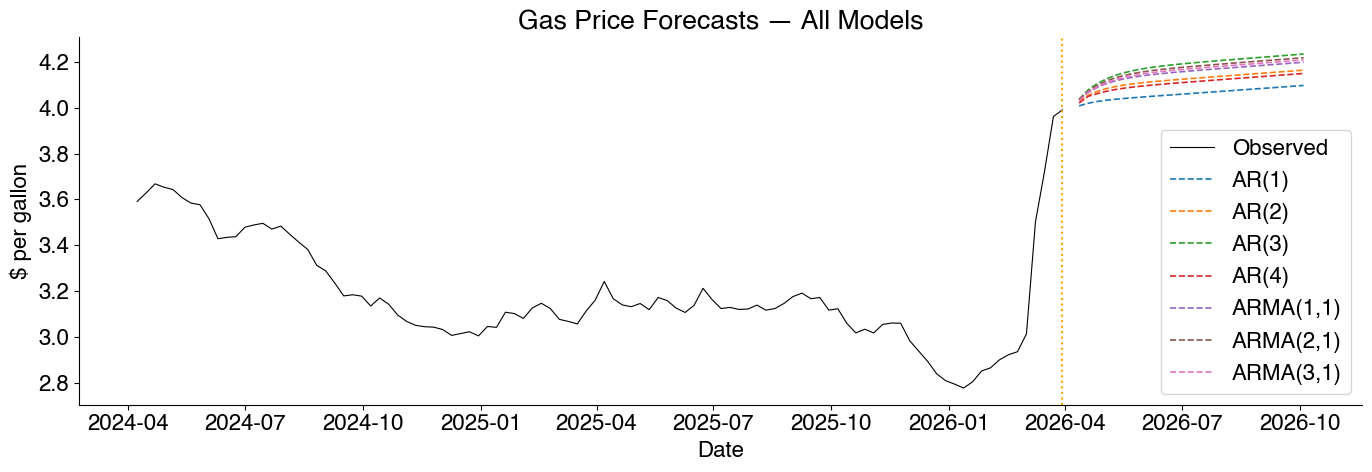

In [184]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(gas.index[-lookback:], y_gas[-lookback:], 'k-', linewidth=0.8, label='Observed')
ax.axvline(gas.index[-1], color='orange', linewidth=1.5, linestyle=':')

for name, order in models_to_test.items():
    m = ARIMA(log_change, order=order).fit()
    fc = m.get_forecast(steps=n_ahead).predicted_mean
    prices = last_price * np.exp(np.cumsum(fc))
    ax.plot(future_dates, prices, '--', linewidth=1.2, label=name)

ax.set(xlabel='Date', ylabel='$ per gallon', title='Gas Price Forecasts — All Models')
ax.legend()
plt.tight_layout()
plt.show()

## Summary

The gas price data has strong autoregressive persistence, but the residuals from pure AR models often retain some short-lag structure. Adding a single MA term can help in selecting a model with relatively fewer parameters compared to a larger AR model.